### Build A Basic Chatbot With Langgraph(GRAPH API)"

In [18]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [19]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function",
    # in the annotation defines how this state key should be updated",
    # (in this case, it appends messages to the list, rather than overwriting them)"
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [20]:
graph_builder

In [21]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [22]:
from langchain_groq import ChatGroq
from langchain.chat_models import  init_chat_model

llm=ChatGroq(model="qwen/qwen3-32b")

In [23]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x111249700>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x111be6c30>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [24]:
llm=init_chat_model("groq:qwen/qwen3-32b")

In [25]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x111be7ec0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x111be7e30>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [26]:
### Node functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [27]:
## add node
graph_builder.add_node("chatbot",chatbot)

## add edge
graph_builder.add_edge(START,"chatbot")

graph_builder.add_edge("chatbot",END)

## compile the graph

graph=graph_builder.compile()


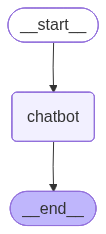

In [28]:
### Visualize the graph
from IPython.display import  Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [29]:
response=graph.invoke({"messages":"Hi"})
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond politely. Let me check the guidelines. I need to be friendly and offer assistance. Maybe say something like "Hello! How can I help you today?" That should work. Keep it simple and open-ended to encourage them to ask questions or share what they need.\n</think>\n\nHello! How can I help you today?'

In [30]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
       print(value["messages"][-1].content)

<think>
Okay, the user sent "Hi how are you?" which is a greeting. I should respond in a friendly way. I need to keep it conversational and not too formal. Maybe start with a cheerful greeting like "Hi there!" or "Hello!" Then offer help. They might need assistance with something specific, so I should ask how I can help them today. Keep it open-ended. Also, since it's the first interaction, make sure to be welcoming and approachable. Avoid using any markdown and keep the response natural. Let me put that together.
</think>

Hi there! I'm doing well, thanks for asking. How can I assist you today? 😊


### Chatbot with tool

In [ ]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

In [ ]:
### define custom function
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int

    Returns:
        output int
    """
    return a * b


In [33]:
tools=[tool,multiply]

In [34]:
llm_with_tool=llm.bind_tools(tools)

llm_with_tool

ValueError: Arg a(int) in docstring not found in function signature.

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


## node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message from the LLM is a tool call -> tools_condition routes to "tools"
    # Otherwise -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")

## compile the graph
graph = builder.compile()


### Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass
